# Image Registration

This notebook shows how an input score card image is loaded and registered onto a defined template (same card). Some parts of the displayed images are masked as they are concerned with names. Registered images are then have the score card table cells extracted and arranged into a grid.



In [1]:
import numpy as np
import cv2
import os, sys
from PIL import Image
import matplotlib.pyplot as plt
from skimage import io, filters, color
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
sys.path.insert(0, str(SCRIPTS_DIR))
temp_path = "..\\data\\Templates"
data_paths = {
    'Data1': "..\\data\\Data1",
    'Data2': "..\\data\\Data2"
}
rawdata_paths = {k: os.path.join(v, "Raw") for k, v in data_paths.items()}
regdata_paths = {k: os.path.join(v, "Registered") for k, v in data_paths.items()}

In [2]:
# v2: Piecewise Homography (split-card) to address crease problem
def register_img(temp_img, samp_images, crease_x):
    orb = cv2.ORB_create(5000)
    # Use FLANN-based matching (faster/better for large feature sets)
    index_params = dict(algorithm=6, table_number=6, key_size=12, multi_probe_level=1)
    search_params = dict(checks=50)
    matcher = cv2.FlannBasedMatcher(index_params, search_params)

    # extract keypoints and descriptors from the template
    temp_kp, temp_des = orb.detectAndCompute(temp_img, None)
    height, width = temp_img.shape[:2]

    # results to be returned
    matched_images = []
    registered_images = []
    for i, samp_img in enumerate(samp_images): 
        # extract keypoints and descriptors from the sample
        samp_kp, samp_des = orb.detectAndCompute(samp_img, None)
        # match descriptors of the template and sample
        matches = matcher.knnMatch(temp_des, samp_des, k=2)
        good_matches = [m for m, n in matches if m.distance < 0.7 * n.distance]
        
        if len(good_matches) > 20:
            match_img = cv2.drawMatches(temp_img, temp_kp, samp_img, samp_kp, good_matches, None, flags=2)
            
            points_temp = np.float32([temp_kp[m.queryIdx].pt for m in good_matches])
            points_samp = np.float32([samp_kp[m.trainIdx].pt for m in good_matches])

            # Split into Left and Right Panes
            left_mask = points_temp[:, 0] < crease_x
            right_mask = points_temp[:, 0] >= crease_x
            reg_img = np.zeros_like(temp_img)

            # Apply TWO Homographies (One for each side of the crease)
            for mask, x_range in [(left_mask, (0, crease_x)), (right_mask, (crease_x, width))]:
                if np.sum(mask) < 4: continue
                
                # Rigidly align just this half
                H, _ = cv2.findHomography(points_samp[mask], points_temp[mask], cv2.RANSAC, 5.0)
                warped = cv2.warpPerspective(samp_img, H, (width, height))
                
                # Stitch into final image
                x1, x2 = x_range
                reg_img[:, x1:x2] = warped[:, x1:x2]

            registered_images.append(reg_img)
            matched_images.append(match_img)
        else:
            print(f"Not enough matches found for sample {i}.")

    return registered_images, matched_images


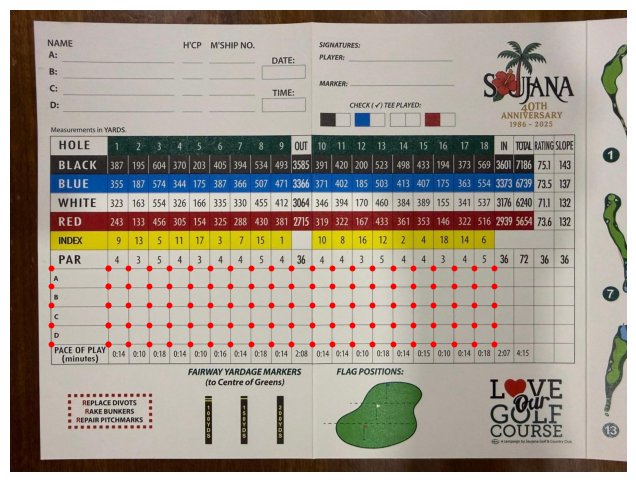

Template shape: (1600, 1199)


In [3]:
def load_img(img_f, img_dir=temp_path, points=None, show=False):
    """
    points: list of lists or array of lists. Inner list must have len 2.
    """
    img_p = os.path.join(img_dir, f"{img_f}.jpeg")
    i = io.imread(img_p)
    if i is None: raise ValueError("Image not found or unable to load.")
    if show:
        plt.figure(figsize=(8, 6))
        plt.imshow(i)

        if points is not None:
            pts = np.array(points)
            plt.scatter(pts[:, 0], pts[:, 1], c='red', s=10)

        plt.axis('off')
        plt.show()
    return i


templates = {}

# DATA2 TEMPLATE (points are hand-picked)
x_pt = [106,254,730,782,1256]
y_pt = [668,716,766,816,866]
crease_x = 782
cells = np.linspace(254, 730, 10).tolist()[1:-1] + np.linspace(782, 1256, 10).tolist()[1:-1]
x_cells = x_pt[1:] + cells
x_cells = sorted(x_pt[1:] + cells)
header_cells = [[round(x),round(y)] for x in x_pt[:2] for y in y_pt]
score_cells = [
    [round(x),round(y)] for x in x_cells for y in y_pt
]

template_points = header_cells + score_cells
pts_template = np.array(template_points)
temp_i = load_img('Data2', points=pts_template, show=True)
height, width = temp_i.shape[0], temp_i.shape[1]
print(f"Template shape: {(width, height)}")
templates['Data2'] = {
    'header_cells': header_cells,
    'score_cells': score_cells,
    'template_shape': (height, width),
    'crease_x': crease_x,
    'temp_i':temp_i
}

## Data2

In [4]:
sample_names = sorted([os.path.splitext(f)[0] for f in os.listdir(rawdata_paths['Data2'])], key=lambda x: int(x.split('_')[1]))
sample_images = [load_img(f, img_dir=rawdata_paths['Data2']) for f in sample_names]
registered_images, matched_images = register_img(templates['Data2']['temp_i'], sample_images, crease_x=templates['Data2']['crease_x'])

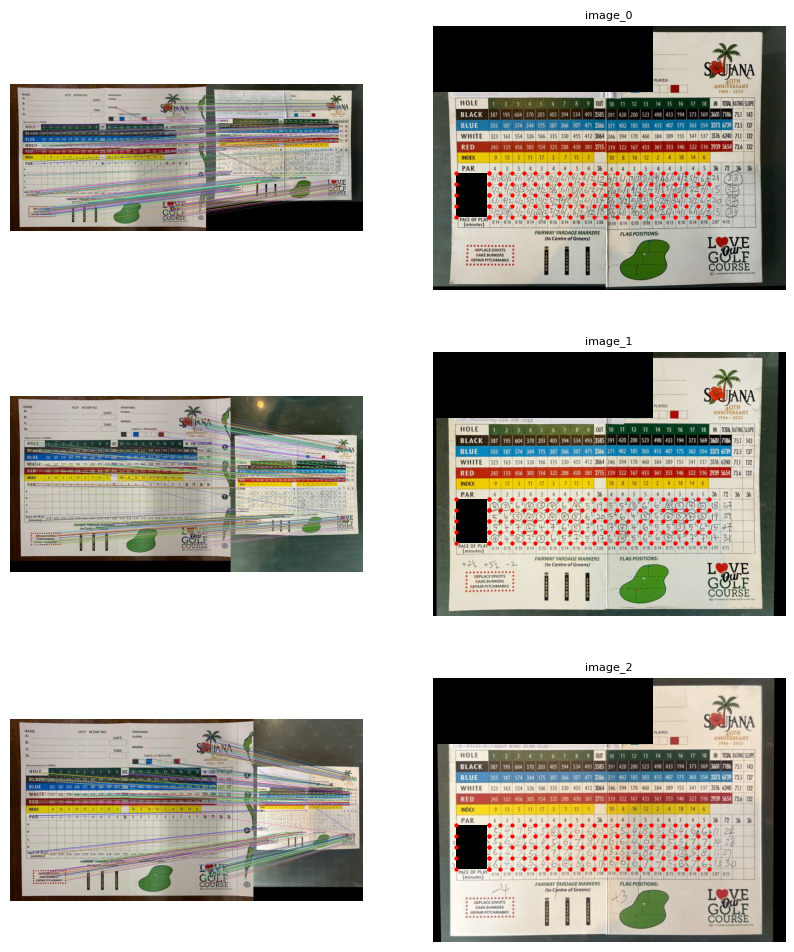

In [ ]:
# visualization: 
rows = len(registered_images[-3:])
cols = 2
fig, ax = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
template_points = templates['Data2']['header_cells'] + templates['Data2']['score_cells']
pts_template = np.array(template_points)
rect2_init = templates['Data2']['header_cells'][0]
rect2_width = templates['Data2']['header_cells'][-1][0] - templates['Data2']['header_cells'][0][0] - 6
rect2_height = templates['Data2']['header_cells'][-1][1] - templates['Data2']['header_cells'][0][1]
for r in range(rows):
    mask_rect1 = plt.Rectangle((0, 0), 1000, 300, edgecolor=None, facecolor='black', linewidth=0)
    mask_rect2 = plt.Rectangle(rect2_init, rect2_width, rect2_height, edgecolor=None, facecolor='black', linewidth=0)
    ax[r,0].imshow(matched_images[r])
    ax[r,1].set_title(sample_names[r], fontsize=8)
    ax[r,1].add_patch(mask_rect1)
    ax[r,1].add_patch(mask_rect2)
    ax[r,1].imshow(registered_images[r])
    # add predefined template points
    ax[r,1].scatter(pts_template[:, 0], pts_template[:, 1], c='red', s=4)
    for c in range(cols): ax[r,c].axis('off')
plt.show()

In [ ]:
# save registered images
from utils import save_images_as_jpeg

save_dir = os.path.join(regdata_paths['Data2'])
save_images_as_jpeg(registered_images, save_dir)

## Cell Extraction

In [19]:
def get_grid_from_points(points):
    pts = np.array(points)

    xs = np.round(pts[:, 0]).astype(int)
    ys = np.round(pts[:, 1]).astype(int)

    x_coords = np.unique(xs)
    y_coords = np.unique(ys)

    return np.sort(x_coords), np.sort(y_coords)

def crop_cells_grid(img, x_coords, y_coords, target_h=28, pad=0):
    grid = []

    for i in range(len(y_coords) - 1):
        row = []
        for j in range(len(x_coords) - 1):
            x1, x2 = x_coords[j] - pad, x_coords[j+1] + pad
            y1, y2 = y_coords[i] - pad, y_coords[i+1] + pad

            cell = img[y1:y2, x1:x2]
            # resize to target height
            h, w = cell.shape[:2]
            scale = target_h / h
            new_w = max(1, int(w * scale))

            cell_resized = cv2.resize(cell, (new_w, target_h), interpolation=cv2.INTER_AREA)
            row.append(cell_resized)
        grid.append(row)

    return grid

reg_img = registered_images[-1]
sx_coords, sy_coords = get_grid_from_points(templates['Data2']['score_cells'])  # score cells
hx_coords, hy_coords = get_grid_from_points(templates['Data2']['header_cells'])  # header cells
score_grid = crop_cells_grid(reg_img, sx_coords, sy_coords, target_h=48, pad=4)
score_grid = [row[:9] + row[10:] for row in score_grid]  # remove half sum column at i=9
header_grid = crop_cells_grid(reg_img, hx_coords, hy_coords, target_h=48, pad=4)

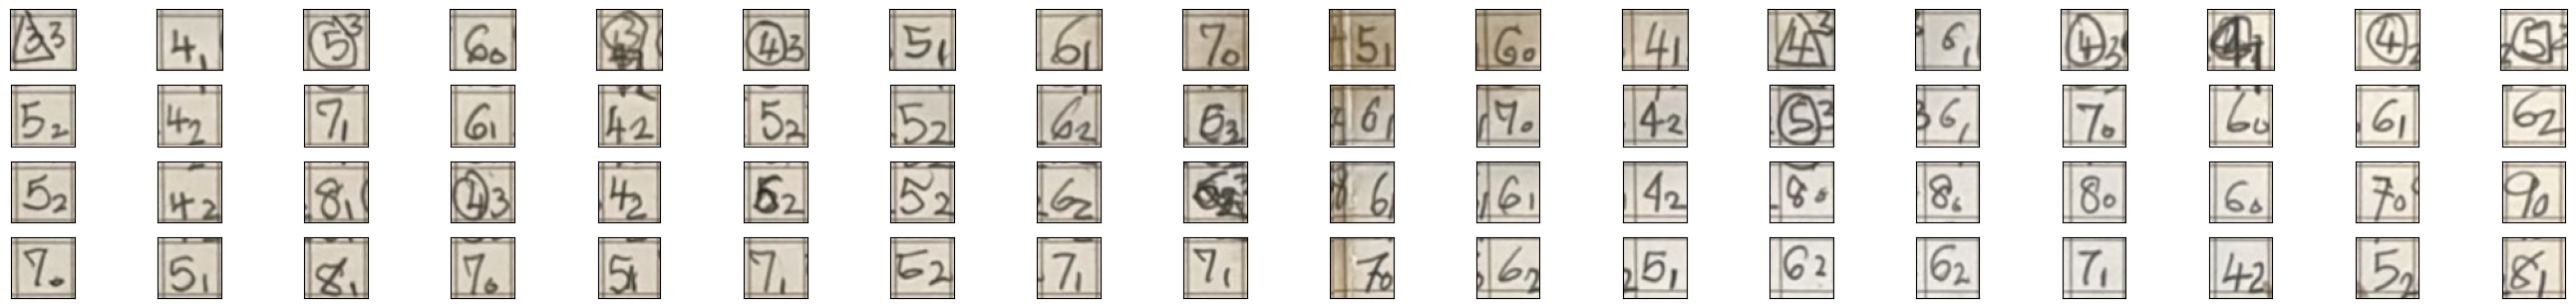

In [21]:
def show_cropped_grid(header_grid, score_grid, show_header=True):
    # 1. Prepare data
    full_display_grid = []
    if show_header:
        for h_row, s_row in zip(header_grid, score_grid):
            full_display_grid.append([h_row[0]] + s_row)
    else:
        full_display_grid = score_grid

    # 2. Determine grid dimensions
    num_rows = len(full_display_grid)
    num_cols = len(full_display_grid[0]) if num_rows > 0 else 0

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 1.5, num_rows * 0.8))
    if num_rows > 1: axes_flat = axes.flatten()
    else: axes_flat = [axes] # Handle single row case

    curr_idx = 0
    for r in range(num_rows):
        for c in range(num_cols):
            ax = axes[r, c] if num_rows > 1 else axes[c]
            cell_img = full_display_grid[r][c]
            ax.imshow(cell_img)
            ax.set_xticks([])
            ax.set_yticks([])
            
    plt.tight_layout()
    plt.show()

show_cropped_grid(header_grid, score_grid, show_header=False)